# Sentiment Dataset Exploration
Dataset: cardiffnlp/tweet_eval (sentiment) <br>
Source: https://huggingface.co/datasets/cardiffnlp/tweet_eval

### Importing the libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

### Importing the datasets (All Splits)

In [7]:
df_train = pd.read_csv('../data/raw/sentiment_train.csv')
df_val = pd.read_csv('../data/raw/sentiment_validation.csv')
df_test = pd.read_csv('../data/raw/sentiment_test.csv')

print('Train Size: ', df_train.shape)
print('Validation Size: ', df_val.shape)
print('Test Size: ', df_test.shape)

Train Size:  (45615, 2)
Validation Size:  (2000, 2)
Test Size:  (12284, 2)


### Preview of Datasets

In [8]:
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
df_train["label_name"] = df_train["label"].map(label_map)

df_train.head()

,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,Positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,Neutral
2,Sorry bout the stream last night I crashed out...,1,Neutral
3,Chase Headley's RBI double in the 8th inning o...,1,Neutral
4,@user Alciato: Bee will invest 150 million in ...,2,Positive


### Class distribution Graph

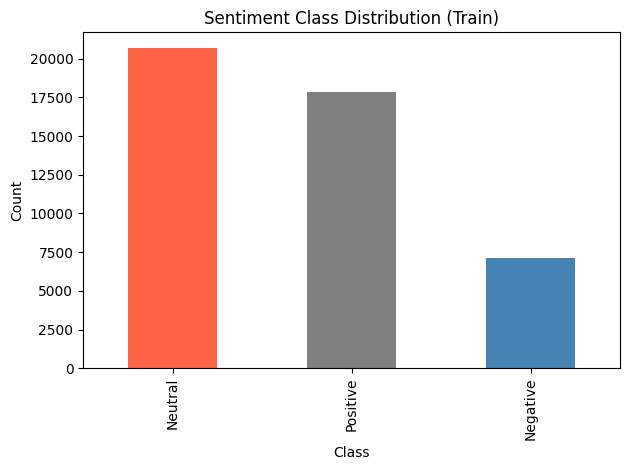

label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [9]:
df_train["label_name"].value_counts().plot(kind="bar", color=["tomato", "gray", "steelblue"])
plt.title("Sentiment Class Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df_train["label_name"].value_counts())

### Observations Noted

Observations
- Class distribution: Neutral > Positive > Negative
- Neutral is the dominant sentiment class in the dataset.
- Positive sentiment is also well represented, while Negative is the minority class. <br>

Mitigation strategies:
- This class imbalance may bias the model toward predicting Neutral more frequently
- Use `class_weight='balanced'` during training
- Monitor macro F1-score instead of relying only on accuracy
- Consider oversampling or data augmentation for the Negative class